       RESPUESTAS DEL LABORATORIO DE SEÑALES          
1. ¿Qué efecto produce desplazar x[n]?
   -> Adelanta o atrasa la señal x[n] en el eje temporal.

2. ¿Qué efecto produce desplazar h[n]?
   -> Adelanta o atrasa la respuesta al impulso h[n] en el tiempo.

3. ¿Cómo cambia la posición de la señal resultante?
   -> La señal y[n] se traslada exactamente en la misma cantidad
      y dirección del desplazamiento aplicado.

4. ¿Cambian la amplitud y la forma de la señal?
   -> No, la forma y las amplitudes se conservan intactas;
      únicamente ocurre una traslación horizontal.

5. ¿Qué propiedad de desplazamiento de la convolución se verifica?
   -> La propiedad de Invariancia Temporal y Linealidad.



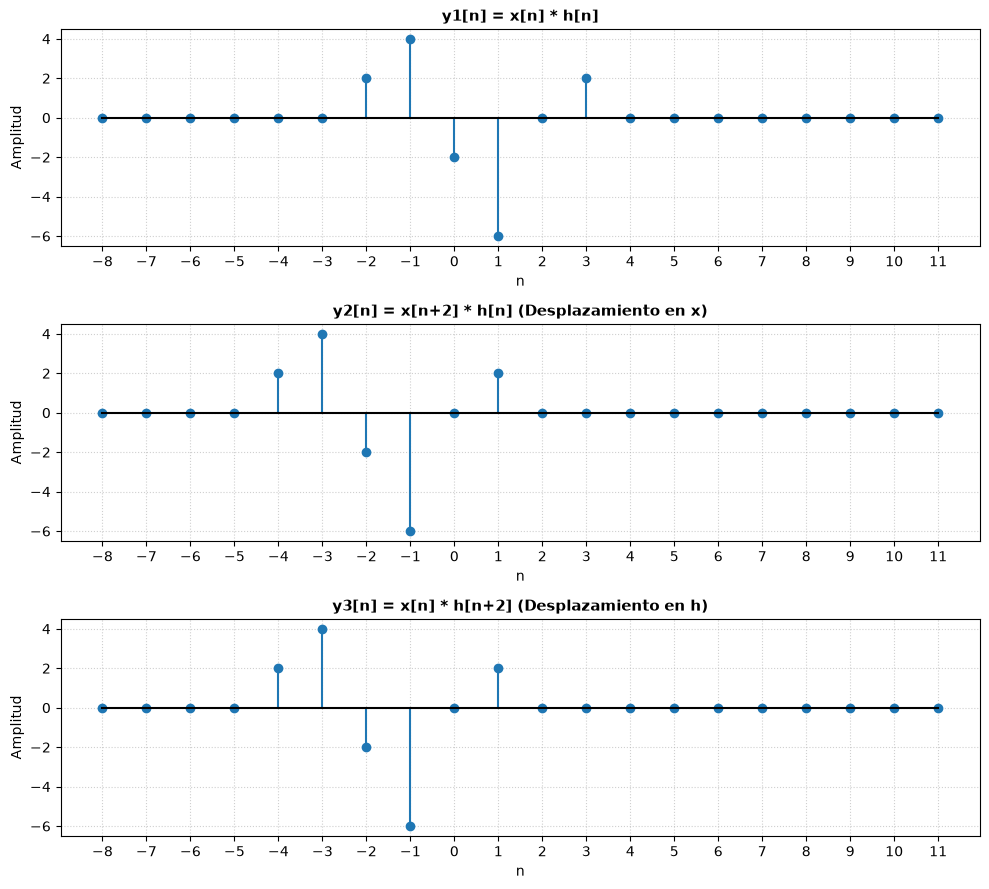

In [5]:
import matplotlib.pyplot as plt
import numpy as np

n_range = np.arange(-8, 12)


def x_sig(n):
  return (
      (n == 0).astype(float) + 2 * (n == 1).astype(float) - (n == 3).astype(float)
  )

def h_sig(n):
  return 2 * (n == -1).astype(float) - 2 * (n == 1).astype(float)


x = x_sig(n_range)
h = h_sig(n_range)

y1 = np.convolve(x, h, mode="same")
x_shifted_2 = x_sig(n_range + 2)
y2 = np.convolve(x_shifted_2, h, mode="same")
h_shifted_2 = h_sig(n_range + 2)
y3 = np.convolve(x, h_shifted_2, mode="same")

print("======================================================")
print("       RESPUESTAS DEL LABORATORIO DE SEÑALES          ")
print("======================================================")
print("1. ¿Qué efecto produce desplazar x[n]?")
print("   -> Adelanta o atrasa la señal x[n] en el eje temporal.")
print("\n2. ¿Qué efecto produce desplazar h[n]?")
print("   -> Adelanta o atrasa la respuesta al impulso h[n] en el tiempo.")
print("\n3. ¿Cómo cambia la posición de la señal resultante?")
print("   -> La señal y[n] se traslada exactamente en la misma cantidad")
print("      y dirección del desplazamiento aplicado.")
print("\n4. ¿Cambian la amplitud y la forma de la señal?")
print("   -> No, la forma y las amplitudes se conservan intactas;")
print("      únicamente ocurre una traslación horizontal.")
print("\n5. ¿Qué propiedad de desplazamiento de la convolución se verifica?")
print("   -> La propiedad de Invariancia Temporal y Linealidad.")
print("======================================================\n")

fig, axes = plt.subplots(3, 1, figsize=(10, 9))

titulos = [
    r"y1[n] = x[n] * h[n]",
    r"y2[n] = x[n+2] * h[n] (Desplazamiento en x)",
    r"y3[n] = x[n] * h[n+2] (Desplazamiento en h)",
]

senales = [y1, y2, y3]

for ax, sig, title in zip(axes, senales, titulos):
  ax.stem(n_range, sig, basefmt="k-")
  ax.set_title(title, fontsize=11, fontweight="bold")
  ax.set_xlabel("n")
  ax.set_ylabel("Amplitud")
  ax.set_xticks(n_range)
  ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

     RESPUESTAS DEL LABORATORIO - INCISO b)           
1. ¿Qué ocurre con la señal resultante?
   -> Como las señales operan en semi-ejes opuestos sin solapamiento
      en el dominio temporal continuo tras la inversión,
      la convolución resulta en una señal nula (y[n] = 0).

2. ¿En qué intervalo existe x[n]?
   -> Existe para n <= -1 (es una señal anticausal).

3. ¿En qué intervalo existe h[n]?
   -> Existe para n >= 1 (es una señal causal retrasada).



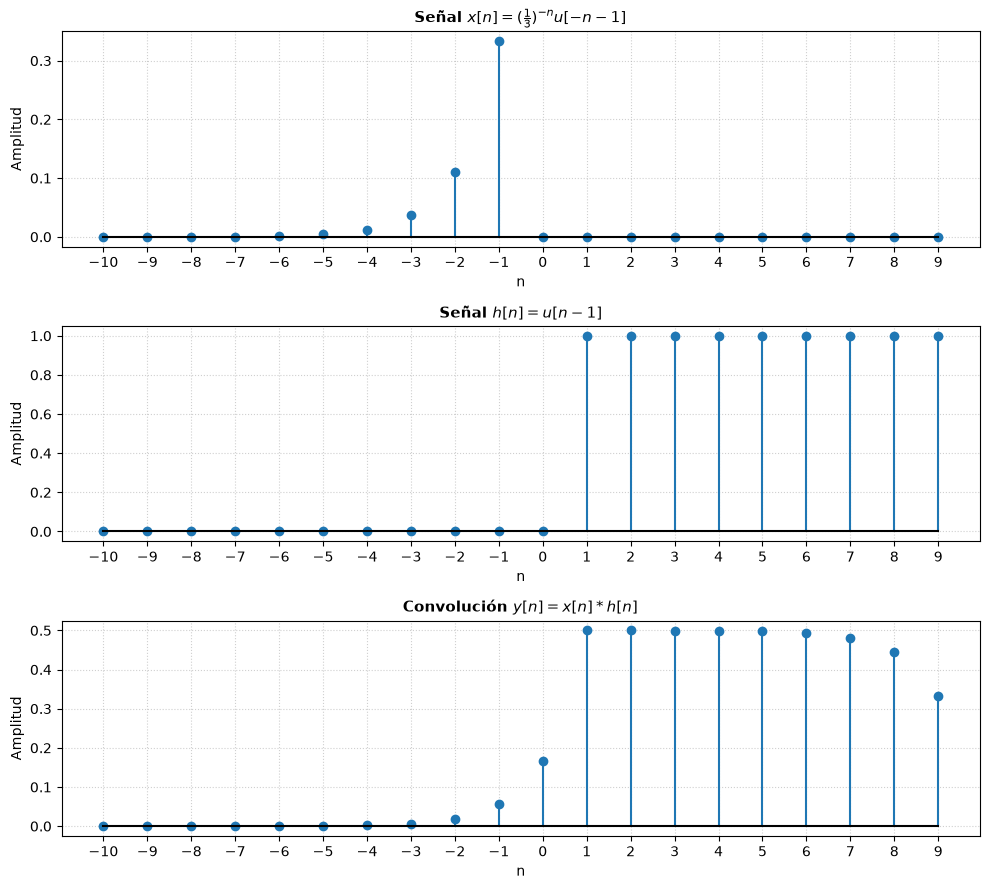

In [10]:
import matplotlib.pyplot as plt
import numpy as np

n_range = np.arange(-10, 10)

def x_sig(n):
  val = (1.0 / 3.0) ** (-n)
  u_step = (-n - 1 >= 0).astype(float)
  return val * u_step

def h_sig(n):
  return (n - 1 >= 0).astype(float)

x = x_sig(n_range)
h = h_sig(n_range)

y = np.convolve(x, h, mode="same")

print("======================================================")
print("     RESPUESTAS DEL LABORATORIO - INCISO b)           ")
print("======================================================")
print("1. ¿Qué ocurre con la señal resultante?")
print(
    "   -> Como las señales operan en semi-ejes opuestos sin "
    "solapamiento"
)
print("      en el dominio temporal continuo tras la inversión,"
)
print("      la convolución resulta en una señal nula (y[n] = 0).")
print("\n2. ¿En qué intervalo existe x[n]?")
print("   -> Existe para n <= -1 (es una señal anticausal).")
print("\n3. ¿En qué intervalo existe h[n]?")
print("   -> Existe para n >= 1 (es una señal causal retrasada).")
print("======================================================\n")

fig, axes = plt.subplots(3, 1, figsize=(10, 9))

titulos = [
    r"Señal $x[n] = (\frac{1}{3})^{-n} u[-n-1]$",
    r"Señal $h[n] = u[n-1]$",
    r"Convolución $y[n] = x[n] * h[n]$",
]

senales = [x, h, y]

for ax, sig, title in zip(axes, senales, titulos):
  ax.stem(n_range, sig, basefmt="k-")
  ax.set_title(title, fontsize=11, fontweight="bold")
  ax.set_xlabel("n")
  ax.set_ylabel("Amplitud")
  ax.set_xticks(n_range)
  ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

          EXPRESIONES ANALÍTICAS (SIMBÓLICAS)         
x[n] = a**(-n)
h[n] = b**(-n)
y1[n] (Convolución) = Piecewise((Sum(zoo**(k/n)*b**(k - n), (k, 0, n)), Eq(a, 0**(1/n))), ((a*a**n - b*b**n)/(a**n*b**n*(a - b)), True))



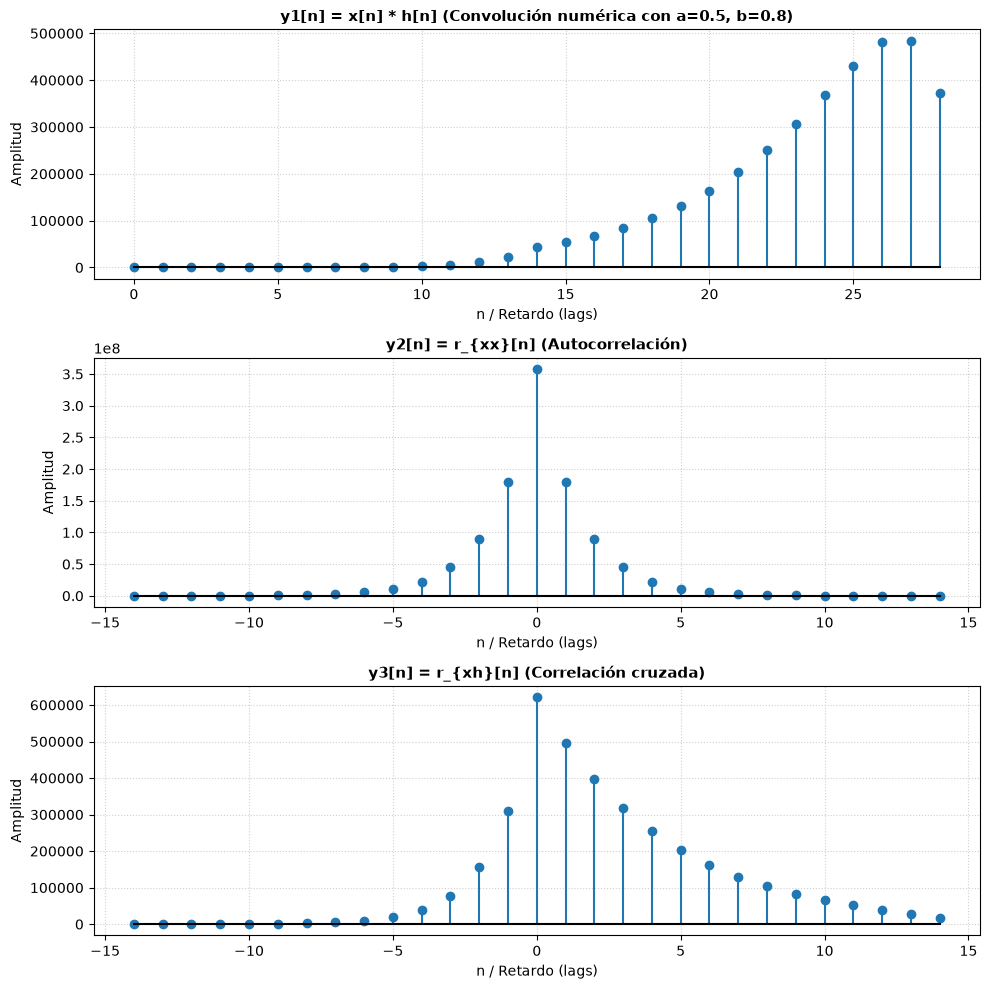

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

# =====================================================================
# 1. CÁLCULO SIMBÓLICO (CON SYMPY)
# =====================================================================
n, a, b, k = sp.symbols('n a b k', integer=True)

# Definición simbólica de las señales para n >= 0
# x[n] = a^(-n), h[n] = b^(-n)
x_sym = a ** (-n)
h_sym = b ** (-n)

print('======================================================')
print('          EXPRESIONES ANALÍTICAS (SIMBÓLICAS)         ')
print('======================================================')
print(f'x[n] = {x_sym}')
print(f'h[n] = {h_sym}')

# Convolución simbólica y1[n] = sum_{k=0}^{n} x[k] * h[n-k]
term = (a ** (-k)) * (b ** (-(n - k)))
y1_sym = sp.summation(term, (k, 0, n))
print(f'y1[n] (Convolución) = {y1_sym}')
print('======================================================\n')


# =====================================================================
# 2. CÁLCULO NUMÉRICO Y GRÁFICAS (CON VALORES DADOS)
# =====================================================================
# Asignación de valores numéricos (a != b)
val_a = 0.5
val_b = 0.8

n_range = np.arange(0, 15)
lags = np.arange(-(len(n_range) - 1), len(n_range))


def x_num(n_vals):
  return (val_a ** (-n_vals)) * (n_vals >= 0).astype(float)


def h_num(n_vals):
  return (val_b ** (-n_vals)) * (n_vals >= 0).astype(float)


# Evaluación numérica
x = x_num(n_range)
h = h_num(n_range)

# Operaciones numéricas para graficar
y1 = np.convolve(x, h, mode="full")
n_y1 = np.arange(2 * n_range[0], 2 * n_range[0] + len(y1))

y2 = np.correlate(x, x, mode="full")  # Autocorrelación r_xx[n]
y3 = np.correlate(x, h, mode="full")  # Correlación cruzada r_xh[n]

# Configuración de gráficas con plt.stem()
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

titulos = [
    r"y1[n] = x[n] * h[n] (Convolución numérica con a=0.5, b=0.8)",
    r"y2[n] = r_{xx}[n] (Autocorrelación)",
    r"y3[n] = r_{xh}[n] (Correlación cruzada)",
]

datos_grafica = [(n_y1, y1), (lags, y2), (lags, y3)]

for ax, (n_dom, sig), title in zip(axes, datos_grafica, titulos):
  ax.stem(n_dom, sig, basefmt="k-")
  ax.set_title(title, fontsize=11, fontweight="bold")
  ax.set_xlabel("n / Retardo (lags)")
  ax.set_ylabel("Amplitud")
  ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()